In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#How many passengers survived vs died?--

df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [7]:
#What is the survival rate in percentage?

df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [8]:
#"How many male vs female passengers were there?"
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [9]:
#"How many missing values are in each column?"
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
#"Drop the Cabin column as it has too many missing values"
df = df.drop(columns=['Cabin'])
df.shape

(891, 11)

In [12]:
#"Fill missing Age values with the median age"
df['Age']=df['Age'].fillna(df['Age'].median())
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [13]:
#"Fill missing Embarked values with the most common port (mode)"
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
#"Create a new column FamilySize"
df['FamilySize']=df['SibSp']+df['Parch']+1
df['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
#"Convert Sex column to numbers (male=0, female=1)"
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [19]:
#"What was the survival rate by gender?"
df.groupby('Sex')['Survived'].mean()*100

Sex
0    18.890815
1    74.203822
Name: Survived, dtype: float64

In [20]:
#"Which passenger class had highest survival rate?"
df.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [21]:
#Did passengers who paid higher fares survive more?
df.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

In [22]:
#Which port of embarkation had the highest survival rate?
df.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

In [24]:
#Did Family Size affect survival?
df.groupby('FamilySize')['Survived'].mean() * 100

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

In [25]:
#What was the average age of survivors vs non-survivors?
df.groupby('Survived')['Age'].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [26]:
df['Sex'] = df['Sex'].map({0: 'male', 1: 'female'})

In [27]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

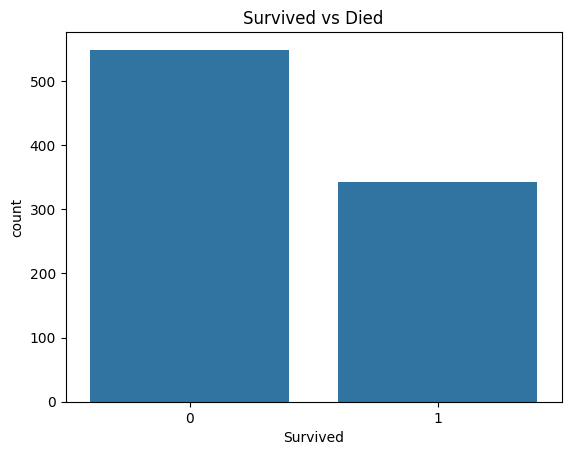

In [28]:
#How many passengers survived and how many died?
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Survived')

plt.title('Survived vs Died')
plt.show()

In [29]:
df['Survival_Status'] = df['Survived'].map({0:'Died', 1:'Survived'})

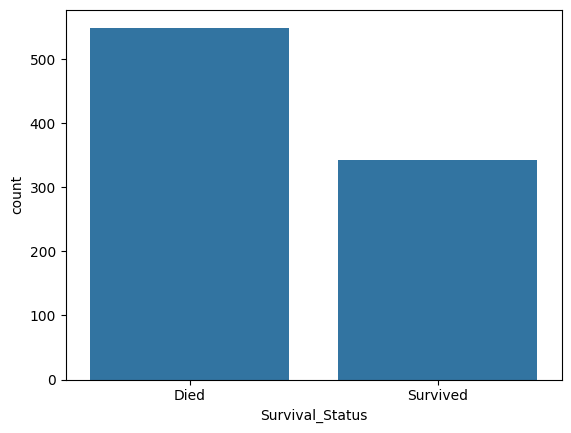

In [30]:
sns.countplot(data=df, x='Survival_Status')
plt.show()

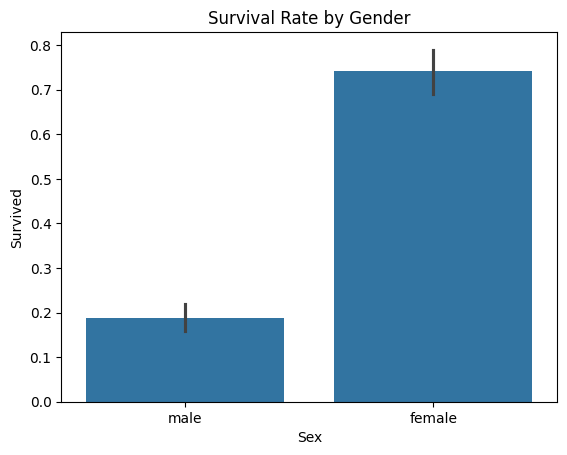

In [31]:
#Survival Rate by Gender
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival Rate by Gender')
plt.show()

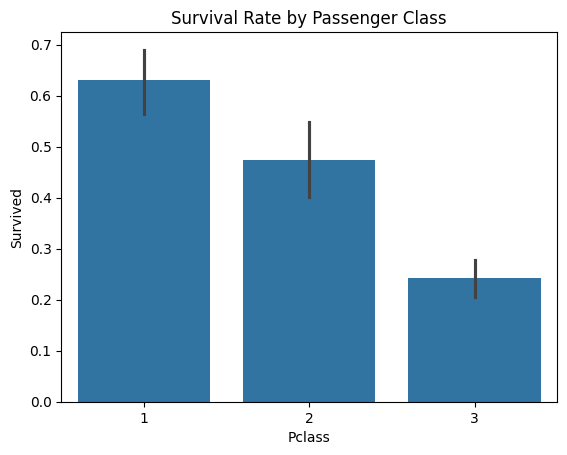

In [32]:
#Survival Rate by Passenger Class
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.show()

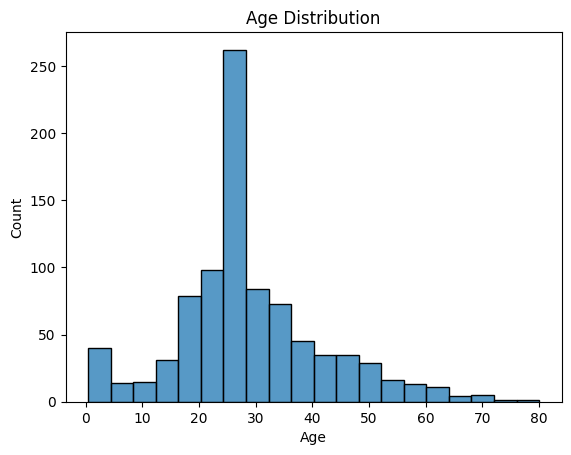

In [33]:
#Age Distribution (Histogram)
sns.histplot(df['Age'], bins=20)

plt.title('Age Distribution')
plt.show()

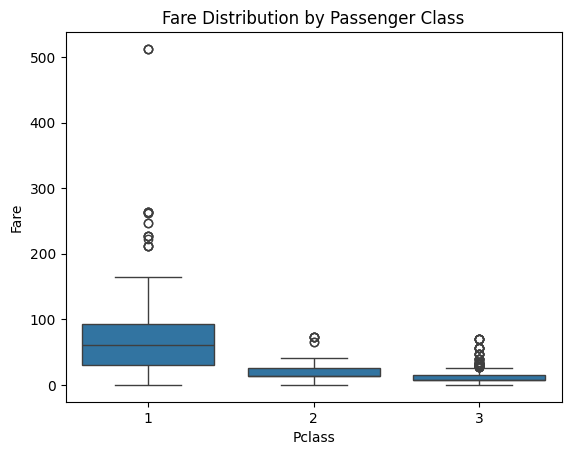

In [34]:
#Fare Distribution by Passenger Class (Boxplot)
sns.boxplot(data=df, x='Pclass', y='Fare')

plt.title('Fare Distribution by Passenger Class')
plt.show()

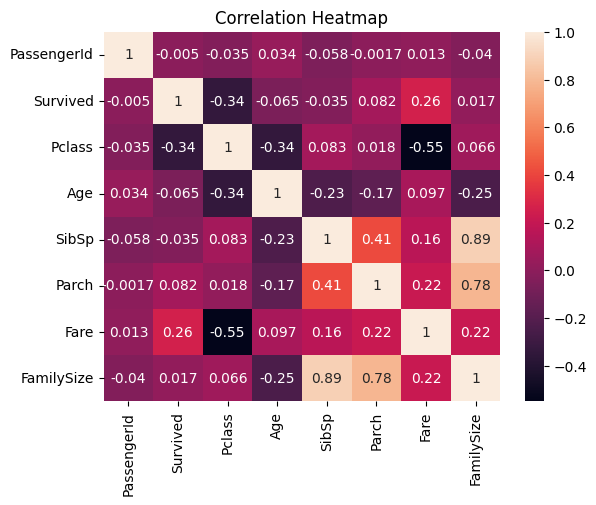

In [35]:
#Which columns are related to each other?Heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

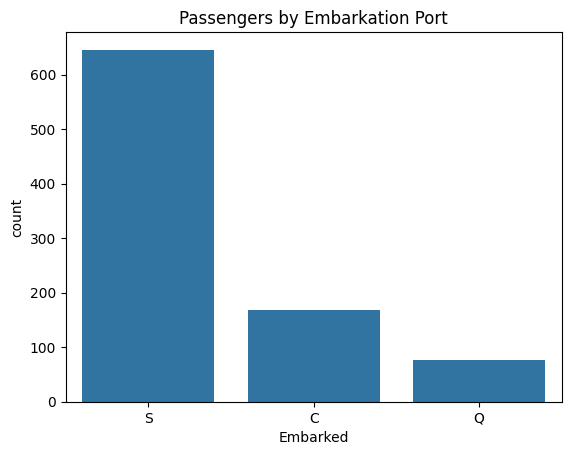

In [36]:
#Passengers by Embarkation Port
sns.countplot(data=df, x='Embarked')

plt.title('Passengers by Embarkation Port')
plt.show()

In [38]:
#Among women in 1st class, what % survived?
df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]['Survived'].mean() * 100

np.float64(96.80851063829788)

In [40]:
#Among men in 3rd class, what % survived?
df[(df['Sex'] == 'male') & (df['Pclass'] == 3)]['Survived'].mean() * 100

np.float64(13.544668587896252)

In [41]:
#Did traveling alone vs with family affect survival?
df.groupby(df['FamilySize'] > 1)['Survived'].mean() * 100

FamilySize
False    30.353818
True     50.564972
Name: Survived, dtype: float64

In [42]:
#Which age group had the best survival rate?
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 19, 59, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

df.groupby('AgeGroup')['Survived'].mean() * 100

AgeGroup
Child     57.971014
Teen      41.052632
Adult     36.519258
Senior    26.923077
Name: Survived, dtype: float64

In [43]:
#Create a full summary table
df.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64